In [ ]:
!pip install langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.3/469.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 16.1 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.0.2 which is incompatible.


A → B → C

A → D → E

C → F

E → F


| Term             | Meaning                                            | Example                                              |
| ---------------- | -------------------------------------------------- | ---------------------------------------------------- |
| **State**        | Shared data passed between tasks                   | `{'number': 12, 'result': 'B path'}`                 |
| **State Schema** | Blueprint (TypedDict) defining what keys can exist | `class MyState(TypedDict): number: int; result: str` |
| **Node/Task**    | Function that reads and writes to the state        | `def taskA(state): ... return state`                 |


State function vs State schema

class MyState(TypedDict, total=False):
    number: int
    result: str


means every task in your graph must:

- accept a dictionary that might have keys "number" and "result",

- return that same dictionary (optionally updated).



In [ ]:
# def taskA(state: MyState):
#     state["number"] = 12
#     return state


# def taskB(state: MyState):
#     state["result"] = "done"
#     return state

# ############ wrong
# def taskB(state):
#     state["Marks"] = "oops"
#     return state


# Step-1: Initialize the StateGraph

**StateGraph(...)**

 call creates a new graph in LangGraph —
and the thing you pass inside (like dict or MyState) tells LangGraph

In [ ]:
from langgraph.graph import StateGraph

graph = StateGraph(dict)


# Step-2: Define the tasks (the functions that each node will run)

**What is “State”?**

- State = a Python dictionary (like memory) that holds your data as it moves through the graph.

You can think of it as a shared workspace where each task (node) can:

- Read data from it

- Write new data into it

- Pass it forward to the next task in the flow

In [ ]:
def taskA(state):
    print("Running A")
    return state

def taskB(state):
    print("Running B")
    return state

def taskC(state):
    print("Running C")
    return state


# Step-3: Add the nodes to the graph


In [ ]:
graph.add_node("A", taskA)
graph.add_node("B", taskB)
graph.add_node("C", taskC)


# Step-4: Define the edges (connections)

In [ ]:
graph.add_edge("A", "B")  # A → B
graph.add_edge("B", "C")  # B → C


# Step-5: Set the entry point (where execution starts)

In [ ]:
graph.set_entry_point("A")


# Step-6: Compile the graph into an executable form

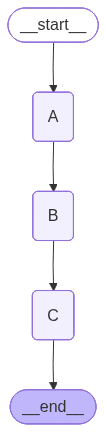

In [ ]:
app = graph.compile()
app

# Case-2:

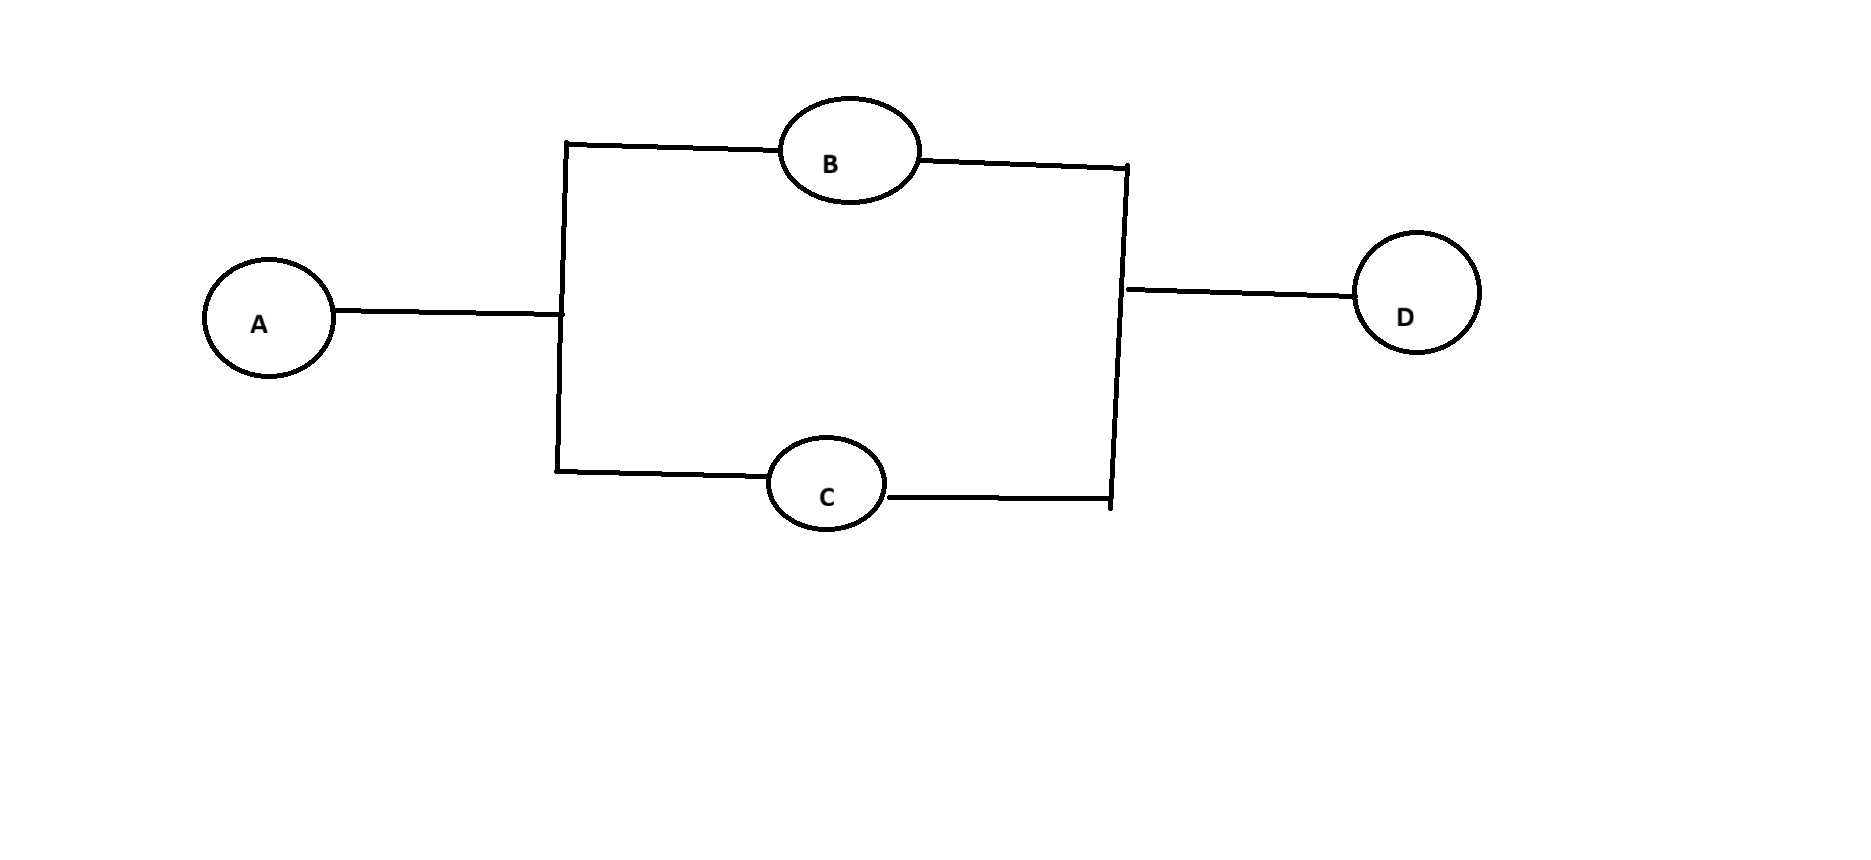


That means:

A runs first

Then both B and D run (in parallel or sequentially depending on the backend)

Finally, both lead to C

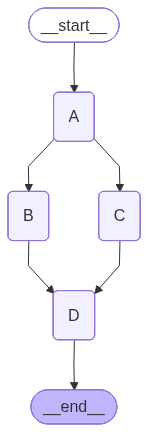

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph

# Define state schema (each node writes to its own field)
class MyState(TypedDict):
    A: str
    B: str
    D: str
    C: str

# Think of it like a database table vs. a data row:

# MyState (the TypedDict) is the table definition (columns and types)

# { "A": "done", ... } is a row of data (actual values)

# LangGraph needs the table definition first — then you pass the row at runtime.

# Define tasks
def taskA(state):
    print("Running A")
    state["A"] = "done"
    return state

def taskB(state):
    print("Running B")
    state["B"] = "done"
    return state

def taskD(state):
    print("Running D")
    state["D"] = "done"
    return state

def taskC(state):
    print("Running C")
    state["C"] = "done"
    print("Final state:", state)
    return state

# 3 Build the graph
graph = StateGraph(state_schema=MyState)
graph.add_node("A", taskA)
graph.add_node("B", taskB)
graph.add_node("D", taskD)
graph.add_node("C", taskC)

graph.add_edge("A", "B")
graph.add_edge("A", "C")
graph.add_edge("B", "D")
graph.add_edge("C", "D")

graph.set_entry_point("A")

# 4️Compile and run
app = graph.compile()
app


In [ ]:
# result = app.invoke({})
# print(result)

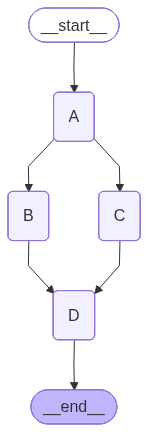

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph

# 1️⃣ Define state schema (each node writes to its own field)
class MyState(TypedDict,total=False):
    A: str
    B: str
    D: str
    C: str

# 2️⃣ Define tasks
def taskA(state: MyState):
    print("Running A")
    state["A"] = "done"
    return state

def taskB(state: MyState):
    print("Running B")
    state["B"] = "done"
    return state

def taskD(state: MyState):
    print("Running D")
    state["D"] = "done"
    return state

def taskC(state: MyState):
    print("Running C")
    state["C"] = "done"
    print("Final state:", state)
    return state

# 3️⃣ Build the graph
graph = StateGraph(state_schema=MyState)
graph.add_node("A", taskA)
graph.add_node("B", taskB)
graph.add_node("D", taskD)
graph.add_node("C", taskC)

graph.add_edge("A", "B")
graph.add_edge("A", "C")
graph.add_edge("B", "D")
graph.add_edge("C", "D")

graph.set_entry_point("A")

# 4️⃣ Compile and run
app = graph.compile()
app


# Case-3

**If condition**

**task**: Will start with A if A is greater tha 10 the go B

OTHERWISE c

- step-1 : Intialize the state with number and result

- step-2: Define 3 tasks A B C

- Step-3: Update the number ket in task A

- Step-4: Update the result key  in task B and B

- Step-5: create decide_task function with if else

- Step-6: Add three Nodes A B and C

- Step-7: Add the conditional edge from A to B or C

- Step-8: then provide the start entry point

- Step-9: Complie the app

- Step-10: invoke the app


In [ ]:
class MyState(TypedDict, total=False):
    number: int
    result: str

def taskA(state):
    print("Running A")
    # Let's give A a number (try changing it to test both paths)
    state["number"] = 12   # change to 5 to test the "C" path
    return state

def taskB(state):
    print("Running B — number was greater than 10")
    state["result"] = "B path"
    return state

def taskC(state):
    print("Running C — number was 10 or less")
    state["result"] = "C path"
    return state


In [ ]:
def decide_next(state: MyState):
    if state["number"] > 10:
        return "B"
    else:
        return "C"





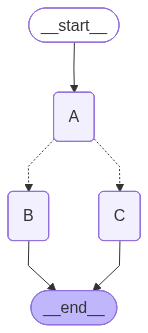

In [ ]:
graph = StateGraph(state_schema=MyState)

graph.add_node("A", taskA)
graph.add_node("B", taskB)
graph.add_node("C", taskC)

graph.add_conditional_edges("A", decide_next, ["B", "C"])
graph.set_entry_point("A")

app = graph.compile()
app


In [ ]:
result = app.invoke({})
print(result)

Running A
Running B — number was greater than 10
{'number': 12, 'result': 'B path'}


In [ ]:
class MyState(TypedDict, total=False):
    number: int
    result: str

def taskA(state):
    print("Running A")
    # Let's give A a number (try changing it to test both paths)
    state["number"] = 12   # change to 5 to test the "C" path
    return state

def taskB(state):
    print("Running B — number was greater than 10")
    state["result"] = "B path"
    return state

def taskC(state):
    print("Running C — number was 10 or less")
    state["result"] = "C path"
    return state

def decide_next(state: MyState):
    if state["number"] > 10:
        return "B"
    else:
        return "C"

graph = StateGraph(state_schema=MyState)

graph.add_node("A", taskA)
graph.add_node("B", taskB)
graph.add_node("C", taskC)

graph.add_conditional_edges("A", decide_next, ["B", "C"])
graph.set_entry_point("A")

app = graph.compile()
app

result = app.invoke({})
print(result)

Running A
Running B — number was greater than 10
{'number': 12, 'result': 'B path'}
